# ASAP7 dendrite ROI identity / same-neuron candidate clustering

This notebook implements a single-session first-pass analysis inspired by Kaspar's suggestion:

> high-pass the compartment signals, compute pairwise ROI correlations, and choose a filter that maximizes the separation between the peak cross-DMD correlations and the cross-DMD correlation distribution.

The main output is a graph of putative same-neuron ROI pairs/components. This is **not proof of shared cellular identity**; it is a ranking/triage tool for reconstruction and for later within-cell versus between-cell analyses.

In [1]:
import os
import sys
import glob
import json
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.utils.utils import save_figure

import matplotlib.pyplot as plt
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [2]:
%matplotlib notebook

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots')

TARGET_MICE = [
    826031,
    826032,
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#     voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"  # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 19 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,50,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


## Single-session configuration

In [6]:
# Choose one session to diagnose.
SESSION_INDEX = 0

# Leave as None to use asset-derived trace path.
MANUAL_TRACE_H5 = None

# Use a shorter window first to verify the workflow; set to None for full-session inference.
IDENTITY_MAX_SECONDS = 600  # None for full session
IDENTITY_START_TIME_SEC = None  # None means from the first available imaging time
VALID_ROIS_ONLY = True

# Candidate high-pass cutoffs suggested by the conversation with Kaspar.
# The filter-selection statistic is computed for each cutoff.
HP_CUTOFFS_HZ = [50, 100, 200, 400, 600]
HP_TARGET_FS_HZ = 2000.0  # after filtering, resample to this approximate rate for correlations
FILTER_ORDER = 4
TIMEBASE_GAP_FACTOR = 5.0
MIN_SEGMENT_SEC = 5.0

# Optional line-noise/harmonic cleanup before correlations.
# For HP=50 Hz, a 60 Hz artifact can inflate broad shared correlations.
APPLY_LINE_NOTCH = True
LINE_FREQ_HZ = 60.0
NOTCH_Q = 30.0
MAX_NOTCH_HZ = 1000.0

# Kaspar-style filter-selection score:
#     (peak cross-DMD correlation - mean cross-DMD correlation) / std cross-DMD correlation
# Use the average of the top K cross-DMD pairs as a less fragile "peak" estimate.
TOP_K_PEAK_PAIRS = 3

# Candidate identity threshold from the selected filter.
# The recommended threshold is the maximum of these three criteria.
IDENTITY_Z_THRESHOLD = 5.0
IDENTITY_ROBUST_Z_THRESHOLD = 6.0
IDENTITY_NULL_PERCENTILE = 99.5

# Lag diagnostics for top pairs. Same-cell candidates should usually be near zero lag.
RUN_LAG_DIAGNOSTICS = True
LAG_DIAGNOSTICS_TOP_N = 25
MAX_LAG_MS = 10.0

# Trace visualization
PLOT_TOP_N_PAIRS = 8
TRACE_PLOT_START_SEC = 30.0
TRACE_PLOT_WINDOW_SEC = 2.0

OUT_DIR = SAVE_PATH / "asap7_dendrite_roi_identity_clustering"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUT_DIR)

Output directory: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_dendrite_roi_identity_clustering


## Helper functions

In [7]:
from scipy import signal as scipy_signal

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def _maybe_get(obj, name, default=None):
    """Safely get attr or dict key from an asset-like object."""
    if hasattr(obj, name):
        return getattr(obj, name)
    if isinstance(obj, dict) and name in obj:
        return obj[name]
    return default


def resolve_voltage_h5(asset, trace_variant=TRACE_VARIANT, session_trace_h5=SESSION_TRACE_H5):
    """
    Resolve the session-long voltage trace H5 path.

    Expected filename:
        voltage_session_traces_{TRACE_VARIANT}.h5

    Uses SESSION_TRACE_H5 if provided; otherwise tries asset.derived_dir / "voltage".
    """
    if session_trace_h5 is not None:
        path = Path(session_trace_h5)
        if not path.exists():
            raise FileNotFoundError(path)
        return path

    derived_dir = _maybe_get(asset, "derived_dir", None)
    if derived_dir is None:
        raise ValueError("Could not find asset.derived_dir. Set SESSION_TRACE_H5 manually.")

    derived_dir = Path(derived_dir)
    candidates = [
        derived_dir / "voltage" / f"voltage_session_traces_{trace_variant}.h5",
        derived_dir / f"voltage_session_traces_{trace_variant}.h5",
    ]

    for path in candidates:
        if path.exists():
            return path

    print("Tried:")
    for path in candidates:
        print("  ", path)
    raise FileNotFoundError("Could not resolve voltage session trace H5.")


def _decode_roi_ids(roi_ids):
    """Decode ROI ids from HDF5 bytes/strings into a clean numpy string array."""
    out = []
    for x in roi_ids:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.asarray(out, dtype=str)


def _get_dmd_keys(h5):
    """Return sorted DMD group names."""
    return sorted([k for k in h5.keys() if k.upper().startswith("DMD")])


def _estimate_fs_from_timebase(t, n_check=200_000):
    """Estimate sampling rate from the start of a timebase vector."""
    n = min(int(n_check), len(t))
    tt = np.asarray(t[:n], dtype=np.float64)
    dt = np.diff(tt)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        raise ValueError("Could not estimate sampling rate from timebase.")
    median_dt = float(np.nanmedian(dt))
    fs = 1.0 / median_dt
    return fs, median_dt


def _infer_trace_layout(y_ds, t_ds):
    """
    Infer whether the trace dataset is ROI x time or time x ROI.

    Returns
    -------
    layout : str
        Either "roi_time" or "time_roi".
    n_rois : int
    n_time : int
    """
    n_time = int(t_ds.shape[0])

    if y_ds.shape[-1] == n_time:
        return "roi_time", int(y_ds.shape[0]), n_time
    if y_ds.shape[0] == n_time:
        return "time_roi", int(y_ds.shape[1]), n_time

    raise ValueError(
        f"Could not infer trace layout. Trace shape={y_ds.shape}, "
        f"timebase length={n_time}"
    )


def _read_roi_trace(y_ds, roi_index, layout, n_time_use=None):
    """Read one ROI trace from an HDF5 dataset."""
    if n_time_use is None:
        n_time_use = y_ds.shape[-1] if layout == "roi_time" else y_ds.shape[0]

    if layout == "roi_time":
        y = np.asarray(y_ds[roi_index, :n_time_use], dtype=np.float32)
    elif layout == "time_roi":
        y = np.asarray(y_ds[:n_time_use, roi_index], dtype=np.float32)
    else:
        raise ValueError(f"Unknown layout: {layout}")

    return y


def _interp_nans_1d(y):
    """Interpolate NaNs/infs in a 1D trace."""
    y = np.asarray(y, dtype=np.float32)
    finite = np.isfinite(y)

    if finite.all():
        return y
    if finite.sum() < 2:
        return np.zeros_like(y, dtype=np.float32)

    x = np.arange(y.size)
    y = y.copy()
    y[~finite] = np.interp(x[~finite], x[finite], y[finite]).astype(np.float32)
    return y


def _find_timebase_segments(t, fs_hz, gap_factor=5.0, min_segment_sec=2.0):
    """
    Find contiguous sample segments from a timebase.

    Boundaries are detected when dt is much larger than the nominal sampling interval.
    """
    t = np.asarray(t, dtype=np.float64)
    dt = np.diff(t)

    nominal_dt = 1.0 / float(fs_hz)
    gap_threshold = gap_factor * nominal_dt
    gap_locs = np.where(dt > gap_threshold)[0]

    starts = np.r_[0, gap_locs + 1]
    stops = np.r_[gap_locs + 1, len(t)]

    min_samples = max(2, int(np.ceil(min_segment_sec * fs_hz)))
    keep = (stops - starts) >= min_samples
    starts = starts[keep]
    stops = stops[keep]

    segments = np.column_stack([starts, stops]).astype(np.int64)
    audit = {
        "nominal_dt_sec": nominal_dt,
        "gap_threshold_sec": gap_threshold,
        "n_detected_gaps": int(len(gap_locs)),
        "n_kept_segments": int(len(segments)),
        "min_segment_sec": float(min_segment_sec),
        "max_dt_sec": float(np.nanmax(dt)) if dt.size else np.nan,
        "median_dt_sec": float(np.nanmedian(dt)) if dt.size else np.nan,
    }
    return segments, audit


def robust_zscore_rows(X, eps=1e-6):
    """Median/MAD z-score each ROI row. Useful before averaging ROIs into a DMD population signal."""
    X = np.asarray(X, dtype=np.float32)
    med = np.nanmedian(X, axis=1, keepdims=True)
    mad = np.nanmedian(np.abs(X - med), axis=1, keepdims=True)
    scale = 1.4826 * mad
    scale = np.where(np.isfinite(scale) & (scale > eps), scale, np.nanstd(X, axis=1, keepdims=True))
    scale = np.where(np.isfinite(scale) & (scale > eps), scale, 1.0)
    return ((X - med) / scale).astype(np.float32)


def standardize_rows(X, eps=1e-8):
    """Mean/std standardize rows for correlation/coherence work."""
    X = np.asarray(X, dtype=np.float32)
    mu = np.nanmean(X, axis=1, keepdims=True)
    sd = np.nanstd(X, axis=1, keepdims=True)
    sd = np.where(np.isfinite(sd) & (sd > eps), sd, 1.0)
    Z = (X - mu) / sd
    Z[~np.isfinite(Z)] = 0
    return Z.astype(np.float32)


def preprocess_X_for_psd(X, mode="robust_z"):
    """Preprocess ROI x time matrix before spectral estimates."""
    if mode == "none":
        return np.asarray(X, dtype=np.float32)
    if mode == "demean":
        X = np.asarray(X, dtype=np.float32)
        return (X - np.nanmean(X, axis=1, keepdims=True)).astype(np.float32)
    if mode == "zscore":
        return standardize_rows(X)
    if mode == "robust_z":
        return robust_zscore_rows(X)
    raise ValueError(f"Unknown mode: {mode}")


def _resample_poly_1d(y, down):
    """Anti-aliased integer downsampling using scipy.signal.resample_poly."""
    y = _interp_nans_1d(y)
    if down <= 1:
        return y.astype(np.float32, copy=False)
    try:
        y_low = scipy_signal.resample_poly(
            y, up=1, down=down, window=("kaiser", 8.6), padtype="line"
        )
    except TypeError:
        y_low = scipy_signal.resample_poly(y, up=1, down=down, window=("kaiser", 8.6))
    return y_low.astype(np.float32, copy=False)

## Resolve selected session

In [8]:
asset = assets[SESSION_INDEX]
row = process_df.iloc[SESSION_INDEX]

trace_h5 = Path(MANUAL_TRACE_H5) if MANUAL_TRACE_H5 is not None else resolve_voltage_h5(asset)
print("Selected session index:", SESSION_INDEX)
display(row)
print("Trace H5:", trace_h5)

Selected session index: 0


session_id                                     826031_2026-01-30_15-04-02
subject_id                                                         826031
session_#                                                               2
session_date                                          2026-01-30 00:00:00
indicator1                                                         ASAP7y
indicator2                                                            NaN
dmd1_depth                                                             50
dmd2_depth                                                            250
paradigm                                         change_detection_passive
session_type                                                     familiar
stimulus                                                         images_A
experimentor                                               Andrew Shelton
instrument_name                                              slap2_albert
instrument_id                         

Trace H5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


In [9]:
def inspect_voltage_h5(trace_h5, signal=SIGNAL):
    """Inspect DMD groups without loading full traces."""
    rows = []
    with h5py.File(trace_h5, "r") as h5:
        for dmd in _get_dmd_keys(h5):
            g = h5[dmd]
            if signal not in g:
                continue
            y_ds = g[signal]
            t_ds = g["timebase_sec"]
            layout, n_rois, n_time = _infer_trace_layout(y_ds, t_ds)
            fs, dt = _estimate_fs_from_timebase(t_ds)
            t0 = float(t_ds[0])
            t1 = float(t_ds[n_time - 1])
            valid = np.asarray(g["valid_rois_mask"][:], dtype=bool) if "valid_rois_mask" in g else np.ones(n_rois, dtype=bool)
            rows.append({
                "dmd": dmd,
                "layout": layout,
                "n_rois": n_rois,
                "n_valid_rois": int(np.sum(valid)),
                "n_samples": n_time,
                "fs_hz": fs,
                "t0_sec": t0,
                "t1_sec": t1,
                "duration_sec": t1 - t0,
                "available_keys": ", ".join(list(g.keys())),
            })
    return pd.DataFrame(rows)

h5_info = inspect_voltage_h5(trace_h5, signal=SIGNAL)
display(h5_info)

,dmd,layout,n_rois,n_valid_rois,n_samples,fs_hz,t0_sec,t1_sec,duration_sec,available_keys
0,DMD1,roi_time,15,12,19236241,10724.166028,6.386656,1800.114947,1793.728291,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
1,DMD2,roi_time,16,13,19236241,10724.166028,6.386656,1800.114947,1793.728291,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."


## High-rate loading and high-pass/resample processing

In [10]:
def _slice_time_indices(t, start_time_sec=None, max_seconds=None):
    t = np.asarray(t, dtype=float)
    if start_time_sec is None:
        start_idx = 0
        t_start = float(t[0])
    else:
        t_start = float(start_time_sec)
        start_idx = int(np.searchsorted(t, t_start, side="left"))
    if max_seconds is None:
        stop_idx = len(t)
    else:
        stop_time = t_start + float(max_seconds)
        stop_idx = int(np.searchsorted(t, stop_time, side="right"))
    start_idx = max(0, min(start_idx, len(t) - 1))
    stop_idx = max(start_idx + 2, min(stop_idx, len(t)))
    return start_idx, stop_idx


def load_highrate_voltage_session(
    trace_h5,
    signal="dff",
    valid_rois_only=True,
    start_time_sec=None,
    max_seconds=600,
    gap_factor=5.0,
    min_segment_sec=5.0,
):
    """
    Load ROI x time traces from the original high-rate H5 for one session.

    This is intentionally single-session. If memory is tight, start with a shorter
    IDENTITY_MAX_SECONDS, then set it to None once the workflow behaves.
    """
    trace_h5 = Path(trace_h5)
    out = {"trace_h5": trace_h5, "signal": signal, "dmd": {}}

    with h5py.File(trace_h5, "r") as h5:
        dmd_keys = _get_dmd_keys(h5)
        for dmd in dmd_keys:
            g = h5[dmd]
            if signal not in g:
                print(f"Skipping {dmd}: '{signal}' not found.")
                continue
            y_ds = g[signal]
            t_ds = g["timebase_sec"]
            layout, n_rois, n_time = _infer_trace_layout(y_ds, t_ds)

            # Use full timebase for slicing, but load only selected interval.
            t_all = np.asarray(t_ds[:], dtype=np.float64)
            start_idx, stop_idx = _slice_time_indices(t_all, start_time_sec=start_time_sec, max_seconds=max_seconds)
            t = t_all[start_idx:stop_idx]
            fs, dt = _estimate_fs_from_timebase(t)
            segments, audit = _find_timebase_segments(t, fs_hz=fs, gap_factor=gap_factor, min_segment_sec=min_segment_sec)

            roi_ids_all = _decode_roi_ids(g["roi_ids"][:]) if "roi_ids" in g else np.asarray([f"roi_{i}" for i in range(n_rois)], dtype=str)
            if valid_rois_only and "valid_rois_mask" in g:
                valid = np.asarray(g["valid_rois_mask"][:], dtype=bool)
            else:
                valid = np.ones(n_rois, dtype=bool)
            roi_indices = np.where(valid)[0]
            roi_ids = roi_ids_all[roi_indices]

            X = np.empty((len(roi_indices), stop_idx - start_idx), dtype=np.float32)
            iterator = roi_indices
            if tqdm is not None:
                iterator = tqdm(roi_indices, desc=f"Reading {dmd}", leave=False)
            for k, roi_idx in enumerate(iterator):
                if layout == "roi_time":
                    y = np.asarray(y_ds[int(roi_idx), start_idx:stop_idx], dtype=np.float32)
                else:
                    y = np.asarray(y_ds[start_idx:stop_idx, int(roi_idx)], dtype=np.float32)
                X[k] = y

            out["dmd"][dmd] = {
                "X": X,
                "time_sec": t,
                "segments": segments,
                "roi_ids": roi_ids,
                "source_roi_indices": roi_indices.astype(np.int64),
                "fs_hz": float(fs),
                "timebase_audit": audit,
                "start_idx": int(start_idx),
                "stop_idx": int(stop_idx),
            }
            print(f"{dmd}: loaded {X.shape[0]} ROIs x {X.shape[1]} samples; fs={fs:.1f} Hz")
    return out


def _common_segments_from_reference(raw, dmd_ref="DMD1"):
    """Use a reference DMD's contiguous segments, clipped to the common sample count across DMDs."""
    dmds = list(raw["dmd"].keys())
    n_common = min(raw["dmd"][d]["X"].shape[1] for d in dmds)
    segments = np.asarray(raw["dmd"][dmd_ref]["segments"], dtype=np.int64).copy()
    segments[:, 0] = np.clip(segments[:, 0], 0, n_common)
    segments[:, 1] = np.clip(segments[:, 1], 0, n_common)
    segments = segments[(segments[:, 1] - segments[:, 0]) > 1]
    return segments, n_common


def _make_highpass_sos(fs_hz, hp_hz, order=4):
    nyq = 0.5 * float(fs_hz)
    if hp_hz <= 0 or hp_hz >= 0.95 * nyq:
        raise ValueError(f"Invalid high-pass cutoff {hp_hz} Hz for fs={fs_hz} Hz")
    return scipy_signal.butter(order, hp_hz, btype="highpass", fs=fs_hz, output="sos")


def _apply_notches(y, fs_hz, line_freq_hz=60.0, q=30.0, max_notch_hz=1000.0):
    """Apply IIR notch filters at line frequency harmonics."""
    y = np.asarray(y, dtype=np.float32)
    if not APPLY_LINE_NOTCH:
        return y
    nyq = 0.5 * float(fs_hz)
    harmonics = []
    f0 = float(line_freq_hz)
    while f0 < min(max_notch_hz, 0.95 * nyq):
        harmonics.append(f0)
        f0 += float(line_freq_hz)
    out = y.astype(np.float32, copy=False)
    for f0 in harmonics:
        try:
            b, a = scipy_signal.iirnotch(w0=f0, Q=q, fs=fs_hz)
            out = scipy_signal.filtfilt(b, a, out, padtype="odd").astype(np.float32)
        except Exception as exc:
            print(f"Skipping notch {f0:.1f} Hz: {exc}")
    return out


def _filter_resample_segment_matrix(Xseg, fs_hz, hp_hz, target_fs_hz, order=4):
    """High-pass/notch/resample an ROI x time segment."""
    sos = _make_highpass_sos(fs_hz, hp_hz, order=order)
    down = max(1, int(round(float(fs_hz) / float(target_fs_hz))))
    fs_out = float(fs_hz) / down
    rows = []
    for i in range(Xseg.shape[0]):
        y = _interp_nans_1d(Xseg[i])
        y = scipy_signal.sosfiltfilt(sos, y).astype(np.float32)
        y = _apply_notches(y, fs_hz=fs_hz, line_freq_hz=LINE_FREQ_HZ, q=NOTCH_Q, max_notch_hz=MAX_NOTCH_HZ)
        y = _resample_poly_1d(y, down=down)
        rows.append(y)
    min_len = min(len(r) for r in rows)
    return np.vstack([r[:min_len] for r in rows]).astype(np.float32), fs_out


def highpass_resample_all_dmds(raw, hp_hz, target_fs_hz=2000.0, dmd_ref="DMD1"):
    """
    High-pass and resample all DMD ROI traces using common sample segments.

    Filtering is done per segment to avoid filtering across trial/epoch gaps.
    The output concatenates filtered/resampled segments and stores the new segment boundaries.
    """
    dmds = list(raw["dmd"].keys())
    fs = float(raw["dmd"][dmd_ref]["fs_hz"])
    common_segments, n_common = _common_segments_from_reference(raw, dmd_ref=dmd_ref)
    out = {"hp_hz": float(hp_hz), "target_fs_hz": float(target_fs_hz), "fs_hz": None, "segments": None, "dmd": {}}

    segment_lengths_out = None
    for dmd in dmds:
        X = raw["dmd"][dmd]["X"][:, :n_common]
        parts = []
        lengths = []
        iterator = common_segments
        if tqdm is not None:
            iterator = tqdm(common_segments, desc=f"HP {hp_hz:g} Hz {dmd}", leave=False)
        fs_out = None
        for s0, s1 in iterator:
            s0, s1 = int(s0), int(s1)
            if (s1 - s0) < int(MIN_SEGMENT_SEC * fs):
                continue
            Xf_seg, fs_out = _filter_resample_segment_matrix(
                X[:, s0:s1], fs_hz=fs, hp_hz=hp_hz, target_fs_hz=target_fs_hz, order=FILTER_ORDER
            )
            if Xf_seg.shape[1] < 2:
                continue
            parts.append(Xf_seg)
            lengths.append(Xf_seg.shape[1])
        if not parts:
            raise RuntimeError(f"No usable segments after filtering for {dmd}.")
        # If different DMDs produce one-sample differences, clip to the reference segment lengths later.
        out["dmd"][dmd] = {
            "X": parts,
            "segment_lengths": lengths,
            "roi_ids": raw["dmd"][dmd]["roi_ids"],
            "source_roi_indices": raw["dmd"][dmd]["source_roi_indices"],
        }
        out["fs_hz"] = float(fs_out)
        if segment_lengths_out is None:
            segment_lengths_out = lengths

    # Clip all DMDs to common resampled segment lengths and concatenate.
    common_lengths = segment_lengths_out
    for dmd in dmds:
        parts = out["dmd"][dmd]["X"]
        nseg = min(len(parts), len(common_lengths))
        clipped = [parts[k][:, :common_lengths[k]] for k in range(nseg)]
        out["dmd"][dmd]["X"] = np.concatenate(clipped, axis=1).astype(np.float32)

    # Final safety trim in case one DMD had fewer usable segments.
    min_n = min(out["dmd"][d]["X"].shape[1] for d in dmds)
    for dmd in dmds:
        out["dmd"][dmd]["X"] = out["dmd"][dmd]["X"][:, :min_n]

    segs = []
    cursor = 0
    for L in common_lengths:
        if cursor >= min_n:
            break
        stop = min(cursor + int(L), min_n)
        if stop > cursor:
            segs.append((cursor, stop))
        cursor = stop
    out["segments"] = np.asarray(segs, dtype=np.int64)
    out["time_sec"] = np.arange(min_n, dtype=np.float64) / float(out["fs_hz"])
    return out

## Pairwise correlation, filter scan, thresholding, and clustering

In [11]:
def build_combined_roi_matrix(hp):
    """Combine high-pass/resampled DMD matrices into one ROI table and one matrix."""
    rows = []
    X_parts = []
    cursor = 0
    for dmd in sorted(hp["dmd"].keys()):
        X = hp["dmd"][dmd]["X"]
        roi_ids = hp["dmd"][dmd]["roi_ids"]
        src_idx = hp["dmd"][dmd]["source_roi_indices"]
        for i, roi_id in enumerate(roi_ids):
            rows.append({
                "node_index": cursor + i,
                "dmd": dmd,
                "roi_index_loaded": int(i),
                "source_roi_index": int(src_idx[i]),
                "roi_id": str(roi_id),
                "node_label": f"{dmd}:{roi_id}",
            })
        X_parts.append(X)
        cursor += X.shape[0]
    roi_df = pd.DataFrame(rows)
    Xall = np.vstack(X_parts).astype(np.float32)
    return Xall, roi_df


def corr_matrix_from_rows(X):
    """Compute Pearson correlation matrix from ROI x time matrix."""
    Z = standardize_rows(X)
    n = Z.shape[1]
    R = (Z @ Z.T) / max(1, n - 1)
    R = np.clip(R, -1, 1).astype(np.float32)
    return R


def pair_df_from_corr_matrix(R, roi_df):
    """Long pair table from a correlation matrix."""
    rows = []
    n = R.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            dmd_i = roi_df.loc[i, "dmd"]
            dmd_j = roi_df.loc[j, "dmd"]
            if dmd_i == dmd_j:
                pair_class = f"within_{dmd_i}"
            else:
                pair_class = "between_DMDs"
            rows.append({
                "node_i": int(i),
                "node_j": int(j),
                "dmd_i": dmd_i,
                "dmd_j": dmd_j,
                "roi_i_id": roi_df.loc[i, "roi_id"],
                "roi_j_id": roi_df.loc[j, "roi_id"],
                "label_i": roi_df.loc[i, "node_label"],
                "label_j": roi_df.loc[j, "node_label"],
                "pair_class": pair_class,
                "r": float(R[i, j]),
            })
    return pd.DataFrame(rows)


def kaspar_filter_score(pair_df, top_k=3):
    """Compute (peak cross-DMD r - mean cross-DMD r) / sd cross-DMD r."""
    cross = pair_df.loc[pair_df["pair_class"] == "between_DMDs", "r"].dropna().to_numpy(dtype=float)
    if cross.size == 0:
        return {"cross_mean": np.nan, "cross_sd": np.nan, "cross_peak": np.nan, "score": np.nan}
    top_k = max(1, min(int(top_k), cross.size))
    cross_sorted = np.sort(cross)
    peak = float(np.mean(cross_sorted[-top_k:]))
    mean = float(np.mean(cross))
    sd = float(np.std(cross, ddof=1)) if cross.size > 1 else np.nan
    score = (peak - mean) / sd if np.isfinite(sd) and sd > 0 else np.nan
    return {"cross_mean": mean, "cross_sd": sd, "cross_peak": peak, "score": score}


def threshold_from_cross_dmd_distribution(pair_df):
    """Recommend a conservative same-cell threshold from cross-DMD correlations."""
    cross = pair_df.loc[pair_df["pair_class"] == "between_DMDs", "r"].dropna().to_numpy(dtype=float)
    if cross.size == 0:
        raise ValueError("No cross-DMD pairs available for thresholding.")
    mean = float(np.mean(cross))
    sd = float(np.std(cross, ddof=1)) if cross.size > 1 else np.nan
    med = float(np.median(cross))
    mad = float(np.median(np.abs(cross - med)))
    robust_sd = 1.4826 * mad if mad > 0 else sd
    z_thresh = mean + IDENTITY_Z_THRESHOLD * sd if np.isfinite(sd) else np.nan
    robust_thresh = med + IDENTITY_ROBUST_Z_THRESHOLD * robust_sd if np.isfinite(robust_sd) else np.nan
    pct_thresh = float(np.nanpercentile(cross, IDENTITY_NULL_PERCENTILE))
    threshold = float(np.nanmax([z_thresh, robust_thresh, pct_thresh]))
    return {
        "cross_mean": mean,
        "cross_sd": sd,
        "cross_median": med,
        "cross_mad": mad,
        "z_threshold": z_thresh,
        "robust_threshold": robust_thresh,
        "percentile_threshold": pct_thresh,
        "recommended_threshold": threshold,
    }


def connected_components_from_edges(roi_df, edges_df):
    """Union-find connected components from candidate identity edges."""
    parent = {int(i): int(i) for i in roi_df["node_index"]}

    def find(x):
        x = int(x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for _, e in edges_df.iterrows():
        union(int(e["node_i"]), int(e["node_j"]))

    comp_root = {i: find(i) for i in parent}
    roots = {r: k for k, r in enumerate(sorted(set(comp_root.values())))}
    comp_id = {i: roots[r] for i, r in comp_root.items()}
    out = roi_df.copy()
    out["component_id"] = out["node_index"].map(comp_id)
    comp_sizes = out.groupby("component_id")["node_index"].size().rename("component_size")
    out = out.merge(comp_sizes, on="component_id", how="left")
    out["putative_multi_roi_cell"] = out["component_size"] > 1
    return out


def run_filter_scan(raw, hp_cutoffs):
    """Run high-pass cutoff scan and return score table plus pair tables by cutoff."""
    scan_rows = []
    pair_tables = {}
    roi_tables = {}
    hp_cache = {}

    for hp_hz in hp_cutoffs:
        print("=" * 100)
        print(f"High-pass cutoff: {hp_hz:g} Hz")
        hp = highpass_resample_all_dmds(raw, hp_hz=hp_hz, target_fs_hz=HP_TARGET_FS_HZ, dmd_ref="DMD1")
        Xall, roi_df = build_combined_roi_matrix(hp)
        R = corr_matrix_from_rows(Xall)
        pair_df = pair_df_from_corr_matrix(R, roi_df)
        score = kaspar_filter_score(pair_df, top_k=TOP_K_PEAK_PAIRS)
        thresh = threshold_from_cross_dmd_distribution(pair_df)
        scan_rows.append({
            "hp_hz": float(hp_hz),
            "fs_after_resample_hz": float(hp["fs_hz"]),
            "n_rois": int(Xall.shape[0]),
            "n_samples": int(Xall.shape[1]),
            **score,
            **{f"threshold_{k}": v for k, v in thresh.items()},
        })
        pair_tables[hp_hz] = pair_df
        roi_tables[hp_hz] = roi_df
        hp_cache[hp_hz] = hp
        print(pd.DataFrame([scan_rows[-1]]).T)

    scan_df = pd.DataFrame(scan_rows).sort_values("score", ascending=False).reset_index(drop=True)
    return scan_df, pair_tables, roi_tables, hp_cache

## Load selected session and scan high-pass cutoffs

In [12]:
raw = load_highrate_voltage_session(
    trace_h5=trace_h5,
    signal=SIGNAL,
    valid_rois_only=VALID_ROIS_ONLY,
    start_time_sec=IDENTITY_START_TIME_SEC,
    max_seconds=IDENTITY_MAX_SECONDS,
    gap_factor=TIMEBASE_GAP_FACTOR,
    min_segment_sec=MIN_SEGMENT_SEC,
)

scan_df, pair_tables, roi_tables, hp_cache = run_filter_scan(raw, HP_CUTOFFS_HZ)
display(scan_df)

best_hp = float(scan_df.iloc[0]["hp_hz"])
print("Selected high-pass cutoff by Kaspar score:", best_hp, "Hz")

Reading DMD1:   0%|          | 0/12 [00:00<?, ?it/s]

DMD1: loaded 12 ROIs x 6434500 samples; fs=10724.2 Hz


Reading DMD2:   0%|          | 0/13 [00:00<?, ?it/s]

DMD2: loaded 13 ROIs x 6434500 samples; fs=10724.2 Hz
High-pass cutoff: 50 Hz


HP 50 Hz DMD1:   0%|          | 0/1 [00:00<?, ?it/s]

...

HP 600 Hz DMD1:   0%|          | 0/1 [00:00<?, ?it/s]

HP 600 Hz DMD2:   0%|          | 0/1 [00:00<?, ?it/s]

                                            0
hp_hz                            6.000000e+02
fs_after_resample_hz             2.144833e+03
n_rois                           2.500000e+01
n_samples                        1.286900e+06
cross_mean                      -8.210537e-04
cross_sd                         6.341387e-03
cross_peak                       1.463420e-02
score                            2.437203e+00
threshold_cross_mean            -8.210537e-04
threshold_cross_sd               6.341387e-03
threshold_cross_median          -1.107924e-03
threshold_cross_mad              3.040585e-03
threshold_z_threshold            3.088588e-02
threshold_robust_threshold       2.593991e-02
threshold_percentile_threshold   1.495625e-02
threshold_recommended_threshold  3.088588e-02


,hp_hz,fs_after_resample_hz,n_rois,n_samples,cross_mean,cross_sd,cross_peak,score,threshold_cross_mean,threshold_cross_sd,threshold_cross_median,threshold_cross_mad,threshold_z_threshold,threshold_robust_threshold,threshold_percentile_threshold,threshold_recommended_threshold
0,400.0,2144.833206,25,1286900,0.000256,0.007380,0.031342,4.212520,0.000256,0.007380,-0.000670,0.002811,0.037153,0.024339,0.032139,0.037153
1,200.0,2144.833206,25,1286900,-0.000012,0.004472,0.017338,3.879385,-0.000012,0.004472,-0.000654,0.002281,0.022350,0.019634,0.016621,0.022350
2,600.0,2144.833206,25,1286900,-0.000821,0.006341,0.014634,2.437203,-0.000821,0.006341,-0.001108,0.003041,0.030886,0.025940,0.014956,0.030886
3,50.0,2144.833206,25,1286900,0.002229,0.003526,0.010694,2.400989,0.002229,0.003526,0.002061,0.002575,0.019857,0.024972,0.010950,0.024972
4,100.0,2144.833206,25,1286900,-0.000547,0.002312,0.004850,2.334924,-0.000547,0.002312,-0.000506,0.001518,0.011011,0.012996,0.004812,0.012996


Selected high-pass cutoff by Kaspar score: 400.0 Hz


## Visualize filter-selection statistic

<IPython.core.display.Javascript object>


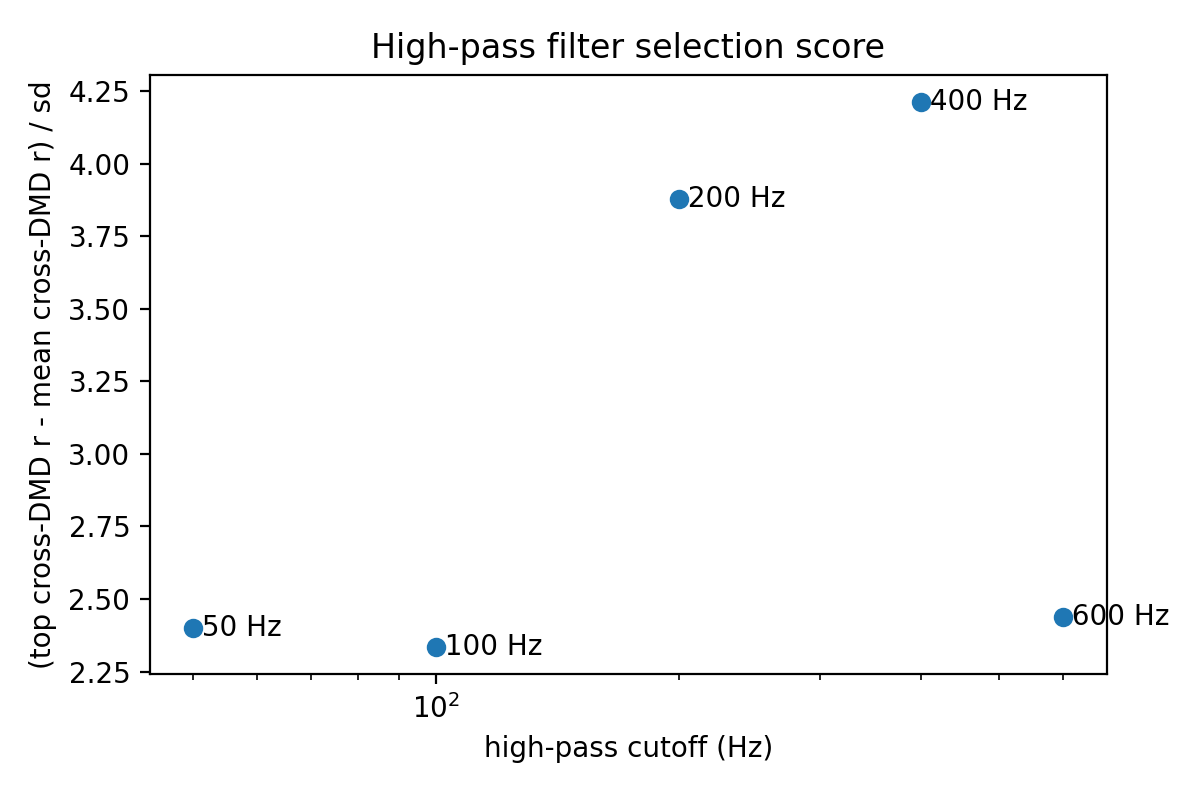

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(scan_df["hp_hz"], scan_df["score"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("high-pass cutoff (Hz)")
ax.set_ylabel("(top cross-DMD r - mean cross-DMD r) / sd")
ax.set_title("High-pass filter selection score")
for _, r in scan_df.iterrows():
    ax.text(r["hp_hz"], r["score"], f" {r['hp_hz']:g} Hz", va="center")
fig.tight_layout()
# save_figure(fig, OUT_DIR, f"{today_str}_session{SESSION_INDEX}_highpass_filter_selection_score")

## Candidate same-neuron threshold and pair table

In [14]:
best_pair_df = pair_tables[best_hp].copy()
best_roi_df = roi_tables[best_hp].copy()
best_hp_data = hp_cache[best_hp]

threshold_info = threshold_from_cross_dmd_distribution(best_pair_df)
identity_threshold = threshold_info["recommended_threshold"]
print("Threshold info:")
display(pd.DataFrame([threshold_info]).T)
print("Recommended identity threshold:", identity_threshold)

best_pair_df["identity_candidate"] = best_pair_df["r"] >= identity_threshold
candidate_edges_df = best_pair_df[best_pair_df["identity_candidate"]].sort_values("r", ascending=False).reset_index(drop=True)
components_df = connected_components_from_edges(best_roi_df, candidate_edges_df)

print("Candidate identity edges:", len(candidate_edges_df))
display(candidate_edges_df)
print("Putative multi-ROI components:")
display(components_df[components_df["putative_multi_roi_cell"]].sort_values(["component_id", "dmd", "roi_id"]))

Threshold info:


,0
cross_mean,0.000256
cross_sd,0.007380
cross_median,-0.000670
cross_mad,0.002811
z_threshold,0.037153
robust_threshold,0.024339
percentile_threshold,0.032139
recommended_threshold,0.037153


Recommended identity threshold: 0.03715333623834534
Candidate identity edges: 14


,node_i,node_j,dmd_i,dmd_j,roi_i_id,roi_j_id,label_i,label_j,pair_class,r,identity_candidate
0,0,1,DMD1,DMD1,DMD1_roi0000,DMD1_roi0001,DMD1:DMD1_roi0000,DMD1:DMD1_roi0001,within_DMD1,0.203457,True
1,1,3,DMD1,DMD1,DMD1_roi0001,DMD1_roi0003,DMD1:DMD1_roi0001,DMD1:DMD1_roi0003,within_DMD1,0.158589,True
2,0,3,DMD1,DMD1,DMD1_roi0000,DMD1_roi0003,DMD1:DMD1_roi0000,DMD1:DMD1_roi0003,within_DMD1,0.127654,True
3,2,3,DMD1,DMD1,DMD1_roi0002,DMD1_roi0003,DMD1:DMD1_roi0002,DMD1:DMD1_roi0003,within_DMD1,0.113870,True
4,13,22,DMD2,DMD2,DMD2_roi0001,DMD2_roi0012,DMD2:DMD2_roi0001,DMD2:DMD2_roi0012,within_DMD2,0.083032,True
5,12,22,DMD2,DMD2,DMD2_roi0000,DMD2_roi0012,DMD2:DMD2_roi0000,DMD2:DMD2_roi0012,within_DMD2,0.079413,True
6,1,2,DMD1,DMD1,DMD1_roi0001,DMD1_roi0002,DMD1:DMD1_roi0001,DMD1:DMD1_roi0002,within_DMD1,0.071239,True
7,14,22,DMD2,DMD2,DMD2_roi0002,DMD2_roi0012,DMD2:DMD2_roi0002,DMD2:DMD2_roi0012,within_DMD2,0.061621,True
8,13,20,DMD2,DMD2,DMD2_roi0001,DMD2_roi0010,DMD2:DMD2_roi0001,DMD2:DMD2_roi0010,within_DMD2,0.057068,True
9,1,8,DMD1,DMD1,DMD1_roi0001,DMD1_roi0011,DMD1:DMD1_roi0001,DMD1:DMD1_roi0011,within_DMD1,0.056380,True


Putative multi-ROI components:


,node_index,dmd,roi_index_loaded,source_roi_index,roi_id,node_label,component_id,component_size,putative_multi_roi_cell
0,0,DMD1,0,0,DMD1_roi0000,DMD1:DMD1_roi0000,0,6,True
1,1,DMD1,1,1,DMD1_roi0001,DMD1:DMD1_roi0001,0,6,True
2,2,DMD1,2,2,DMD1_roi0002,DMD1:DMD1_roi0002,0,6,True
3,3,DMD1,3,3,DMD1_roi0003,DMD1:DMD1_roi0003,0,6,True
5,5,DMD1,5,6,DMD1_roi0006,DMD1:DMD1_roi0006,0,6,True
8,8,DMD1,8,11,DMD1_roi0011,DMD1:DMD1_roi0011,0,6,True
12,12,DMD2,0,0,DMD2_roi0000,DMD2:DMD2_roi0000,7,5,True
13,13,DMD2,1,1,DMD2_roi0001,DMD2:DMD2_roi0001,7,5,True
14,14,DMD2,2,2,DMD2_roi0002,DMD2:DMD2_roi0002,7,5,True
20,20,DMD2,8,10,DMD2_roi0010,DMD2:DMD2_roi0010,7,5,True


## Correlation distributions and cross-DMD matrix

<IPython.core.display.Javascript object>


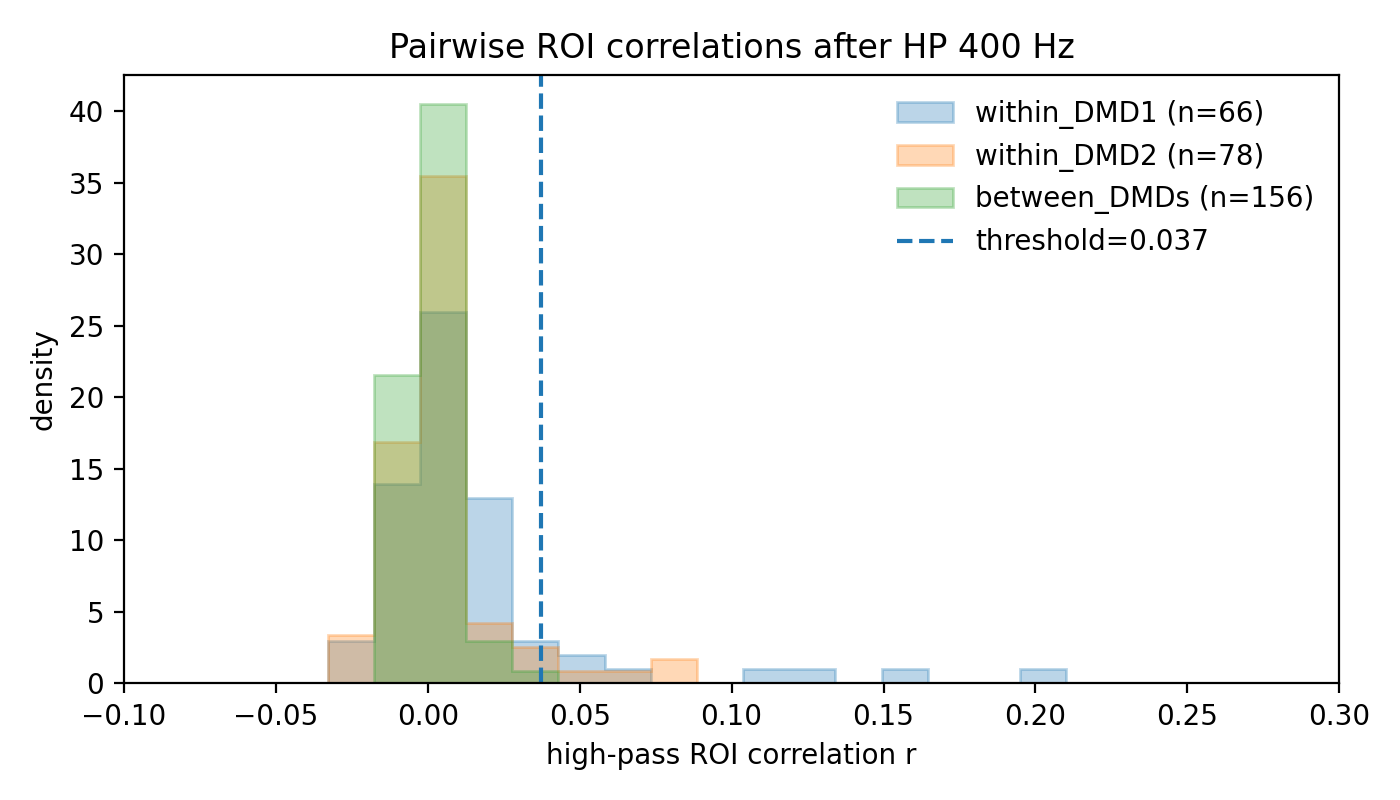

In [15]:
def plot_correlation_distributions(pair_df, threshold, hp_hz):
    fig, ax = plt.subplots(figsize=(7, 4))
    classes = ["within_DMD1", "within_DMD2", "between_DMDs"]
    bins = np.linspace(-0.2, 1.0, 80)
    for cls in classes:
        vals = pair_df.loc[pair_df["pair_class"] == cls, "r"].to_numpy(dtype=float)
        if vals.size:
            ax.hist(vals, bins=bins, histtype="step", density=True,fill=True,alpha=0.3,label=f"{cls} (n={vals.size})")
    ax.axvline(threshold, ls="--", lw=1.5, label=f"threshold={threshold:.3f}")
    ax.set_xlabel("high-pass ROI correlation r")
    ax.set_ylabel("density")
    ax.set_title(f"Pairwise ROI correlations after HP {hp_hz:g} Hz")
    ax.set_xlim(-0.1,0.3)
    ax.legend(frameon=False)
    fig.tight_layout()
#     save_figure(fig, OUT_DIR, f"{today_str}_session{SESSION_INDEX}_hp{hp_hz:g}_pair_corr_distributions")

plot_correlation_distributions(best_pair_df, identity_threshold, best_hp)

In [16]:
best_pair_df

,node_i,node_j,dmd_i,dmd_j,roi_i_id,roi_j_id,label_i,label_j,pair_class,r,identity_candidate
0,0,1,DMD1,DMD1,DMD1_roi0000,DMD1_roi0001,DMD1:DMD1_roi0000,DMD1:DMD1_roi0001,within_DMD1,0.203457,True
1,0,2,DMD1,DMD1,DMD1_roi0000,DMD1_roi0002,DMD1:DMD1_roi0000,DMD1:DMD1_roi0002,within_DMD1,0.053104,True
2,0,3,DMD1,DMD1,DMD1_roi0000,DMD1_roi0003,DMD1:DMD1_roi0000,DMD1:DMD1_roi0003,within_DMD1,0.127654,True
3,0,4,DMD1,DMD1,DMD1_roi0000,DMD1_roi0004,DMD1:DMD1_roi0000,DMD1:DMD1_roi0004,within_DMD1,0.013076,False
4,0,5,DMD1,DMD1,DMD1_roi0000,DMD1_roi0006,DMD1:DMD1_roi0000,DMD1:DMD1_roi0006,within_DMD1,0.025815,False
...,...,...,...,...,...,...,...,...,...,...,...
295,21,23,DMD2,DMD2,DMD2_roi0011,DMD2_roi0014,DMD2:DMD2_roi0011,DMD2:DMD2_roi0014,within_DMD2,-0.005462,False
296,21,24,DMD2,DMD2,DMD2_roi0011,DMD2_roi0015,DMD2:DMD2_roi0011,DMD2:DMD2_roi0015,within_DMD2,0.003363,False
297,22,23,DMD2,DMD2,DMD2_roi0012,DMD2_roi0014,DMD2:DMD2_roi0012,DMD2:DMD2_roi0014,within_DMD2,0.000984,False
298,22,24,DMD2,DMD2,DMD2_roi0012,DMD2_roi0015,DMD2:DMD2_roi0012,DMD2:DMD2_roi0015,within_DMD2,0.003705,False


<IPython.core.display.Javascript object>


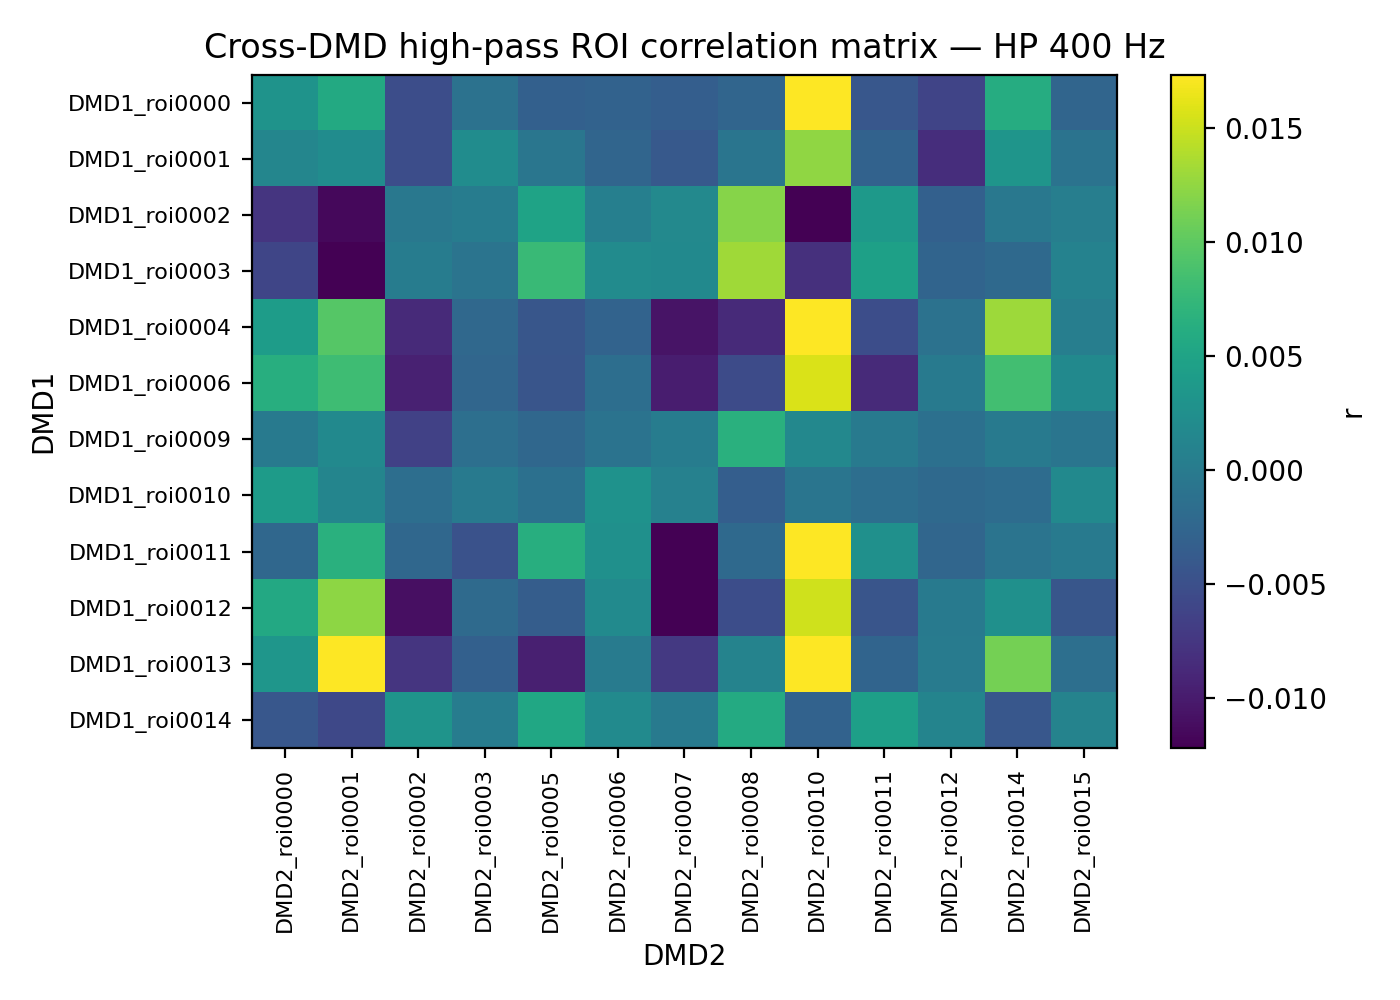

In [17]:
def plot_cross_dmd_corr_matrix(pair_df, roi_df, hp_hz):
    dmds = sorted(roi_df["dmd"].unique())
    if len(dmds) < 2:
        print("Need two DMDs for cross-DMD matrix.")
        return
    d1, d2 = dmds[0], dmds[1]
    r1 = roi_df[roi_df["dmd"] == d1].reset_index(drop=True)
    r2 = roi_df[roi_df["dmd"] == d2].reset_index(drop=True)
    M = np.full((len(r1), len(r2)), np.nan, dtype=float)
    lookup1 = {node: i for i, node in enumerate(r1["node_index"])}
    lookup2 = {node: j for j, node in enumerate(r2["node_index"])}
    for _, p in pair_df[pair_df["pair_class"] == "between_DMDs"].iterrows():
        ni, nj = int(p["node_i"]), int(p["node_j"])
        if ni in lookup1 and nj in lookup2:
            M[lookup1[ni], lookup2[nj]] = p["r"]
        elif nj in lookup1 and ni in lookup2:
            M[lookup1[nj], lookup2[ni]] = p["r"]
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(M, aspect="auto", vmin=np.nanpercentile(M, 2), vmax=np.nanpercentile(M, 98))
    ax.set_yticks(np.arange(len(r1)))
    ax.set_yticklabels(r1["roi_id"], fontsize=8)
    ax.set_xticks(np.arange(len(r2)))
    ax.set_xticklabels(r2["roi_id"], rotation=90, fontsize=8)
    ax.set_xlabel(d2)
    ax.set_ylabel(d1)
    ax.set_title(f"Cross-DMD high-pass ROI correlation matrix — HP {hp_hz:g} Hz")
    fig.colorbar(im, ax=ax, label="r")
    fig.tight_layout()
#     save_figure(fig, OUT_DIR, f"{today_str}_session{SESSION_INDEX}_hp{hp_hz:g}_cross_dmd_corr_matrix")

plot_cross_dmd_corr_matrix(best_pair_df, best_roi_df, best_hp)

## Lag diagnostics for top candidate pairs

In [18]:
def lagged_corr_for_pair(x, y, fs_hz, max_lag_ms=10.0):
    """Compute correlation over small integer lags. Positive lag means y lags x."""
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    max_lag = int(round((max_lag_ms / 1000.0) * fs_hz))
    rows = []
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            xs = x[-lag:]
            ys = y[:lag]
        elif lag > 0:
            xs = x[:-lag]
            ys = y[lag:]
        else:
            xs = x
            ys = y
        if xs.size < 10:
            r = np.nan
        else:
            xs = (xs - np.nanmean(xs)) / (np.nanstd(xs) + 1e-8)
            ys = (ys - np.nanmean(ys)) / (np.nanstd(ys) + 1e-8)
            r = float(np.nanmean(xs * ys))
        rows.append({"lag_samples": lag, "lag_ms": 1000.0 * lag / fs_hz, "r": r})
    out = pd.DataFrame(rows)
    best = out.loc[out["r"].idxmax()].to_dict()
    return out, best


def run_lag_diagnostics_for_top_pairs(hp, pair_df, top_n=25):
    Xall, roi_df = build_combined_roi_matrix(hp)
    top = pair_df.sort_values("r", ascending=False).head(top_n).copy()
    rows = []
    lag_curves = []
    fs = float(hp["fs_hz"])
    for pair_rank, (_, p) in enumerate(top.iterrows(), start=1):
        i, j = int(p["node_i"]), int(p["node_j"])
        curve, best = lagged_corr_for_pair(Xall[i], Xall[j], fs_hz=fs, max_lag_ms=MAX_LAG_MS)
        rows.append({
            "pair_rank": pair_rank,
            "node_i": i,
            "node_j": j,
            "label_i": p["label_i"],
            "label_j": p["label_j"],
            "pair_class": p["pair_class"],
            "zero_lag_r": p["r"],
            "best_lag_ms": best["lag_ms"],
            "best_lag_r": best["r"],
        })
        curve["pair_rank"] = pair_rank
        curve["label_i"] = p["label_i"]
        curve["label_j"] = p["label_j"]
        lag_curves.append(curve)
    return pd.DataFrame(rows), pd.concat(lag_curves, ignore_index=True) if lag_curves else pd.DataFrame()

if RUN_LAG_DIAGNOSTICS:
    lag_summary_df, lag_curves_df = run_lag_diagnostics_for_top_pairs(best_hp_data, best_pair_df, top_n=LAG_DIAGNOSTICS_TOP_N)
    display(lag_summary_df)
else:
    lag_summary_df = pd.DataFrame()
    lag_curves_df = pd.DataFrame()

,pair_rank,node_i,node_j,label_i,label_j,pair_class,zero_lag_r,best_lag_ms,best_lag_r
0,1,0,1,DMD1:DMD1_roi0000,DMD1:DMD1_roi0001,within_DMD1,0.203457,0.000000,0.203454
1,2,1,3,DMD1:DMD1_roi0001,DMD1:DMD1_roi0003,within_DMD1,0.158589,0.000000,0.158586
2,3,0,3,DMD1:DMD1_roi0000,DMD1:DMD1_roi0003,within_DMD1,0.127654,0.000000,0.127652
3,4,2,3,DMD1:DMD1_roi0002,DMD1:DMD1_roi0003,within_DMD1,0.113870,0.000000,0.113869
4,5,13,22,DMD2:DMD2_roi0001,DMD2:DMD2_roi0012,within_DMD2,0.083032,0.000000,0.083030
5,6,12,22,DMD2:DMD2_roi0000,DMD2:DMD2_roi0012,within_DMD2,0.079413,-9.324734,0.098135
6,7,1,2,DMD1:DMD1_roi0001,DMD1:DMD1_roi0002,within_DMD1,0.071239,6.061077,0.083971
7,8,14,22,DMD2:DMD2_roi0002,DMD2:DMD2_roi0012,within_DMD2,0.061621,0.000000,0.061620
8,9,13,20,DMD2:DMD2_roi0001,DMD2:DMD2_roi0010,within_DMD2,0.057068,0.000000,0.057067
9,10,1,8,DMD1:DMD1_roi0001,DMD1:DMD1_roi0011,within_DMD1,0.056380,0.000000,0.056379


<IPython.core.display.Javascript object>


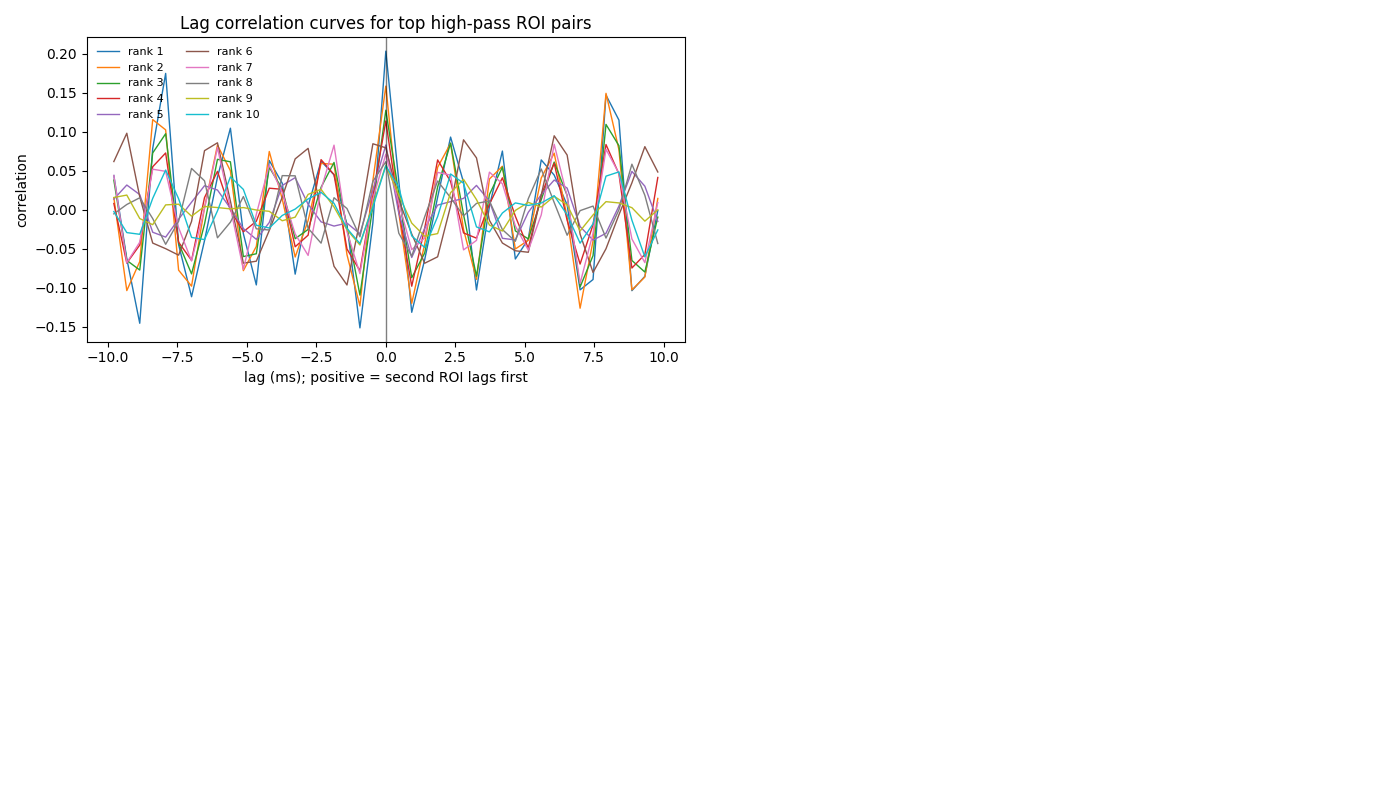

In [19]:
if len(lag_curves_df):
    fig, ax = plt.subplots(figsize=(7, 4))
    for rank in sorted(lag_curves_df["pair_rank"].unique())[:10]:
        d = lag_curves_df[lag_curves_df["pair_rank"] == rank]
        ax.plot(d["lag_ms"], d["r"], lw=1, label=f"rank {rank}")
    ax.axvline(0, color="k", lw=1, alpha=0.5)
    ax.set_xlabel("lag (ms); positive = second ROI lags first")
    ax.set_ylabel("correlation")
    ax.set_title("Lag correlation curves for top high-pass ROI pairs")
    ax.legend(frameon=False, ncol=2, fontsize=8)
    fig.tight_layout()
#     save_figure(fig, OUT_DIR, f"{today_str}_session{SESSION_INDEX}_hp{best_hp:g}_top_pair_lag_curves")

## Plot high-pass traces for top pairs

<IPython.core.display.Javascript object>


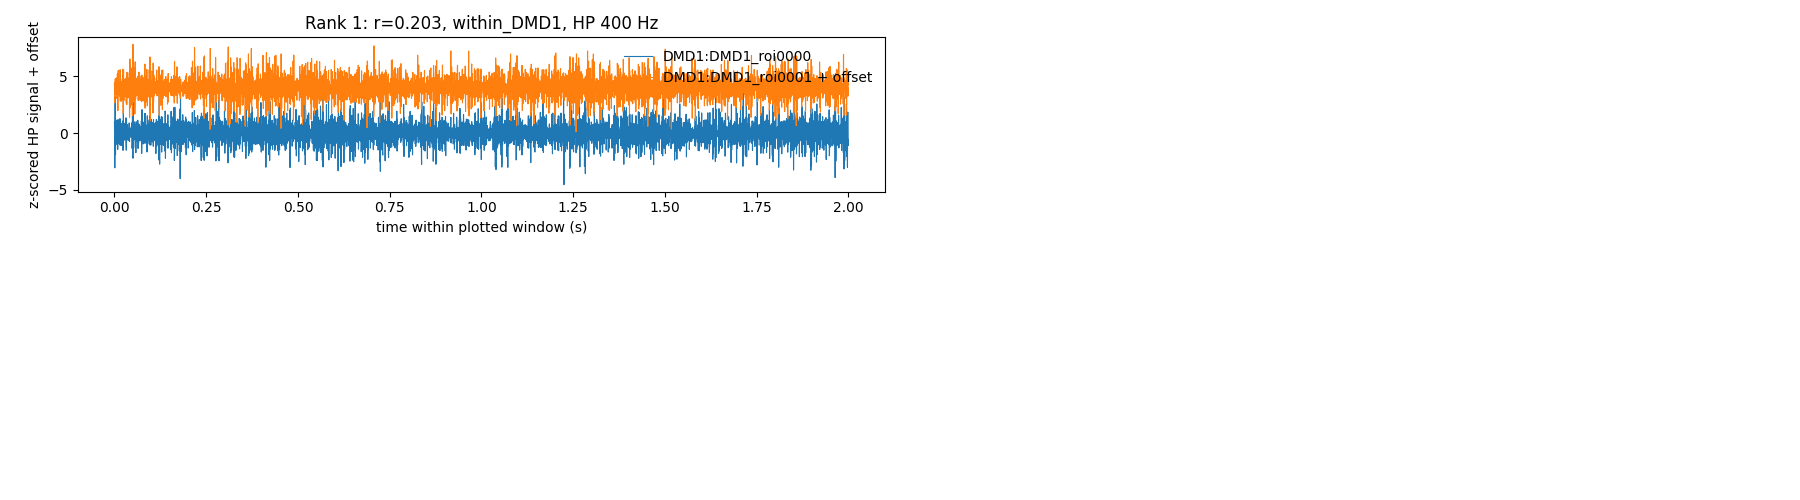

<IPython.core.display.Javascript object>


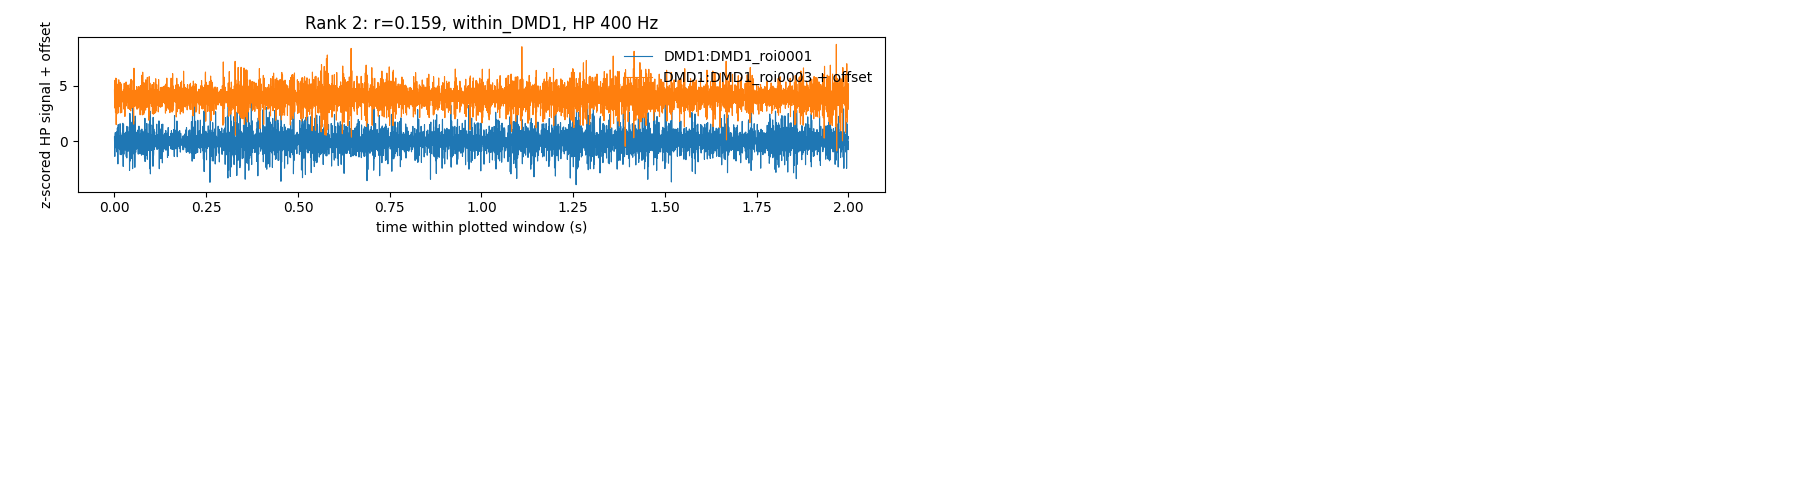

<IPython.core.display.Javascript object>


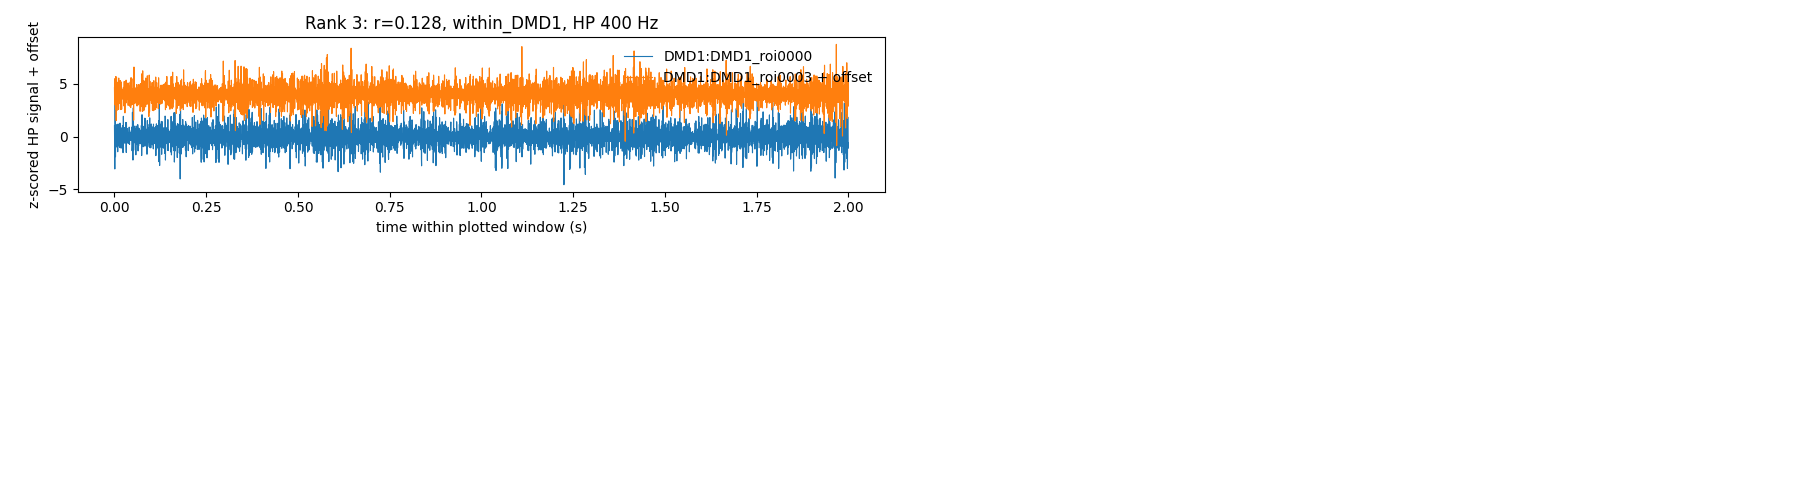

<IPython.core.display.Javascript object>


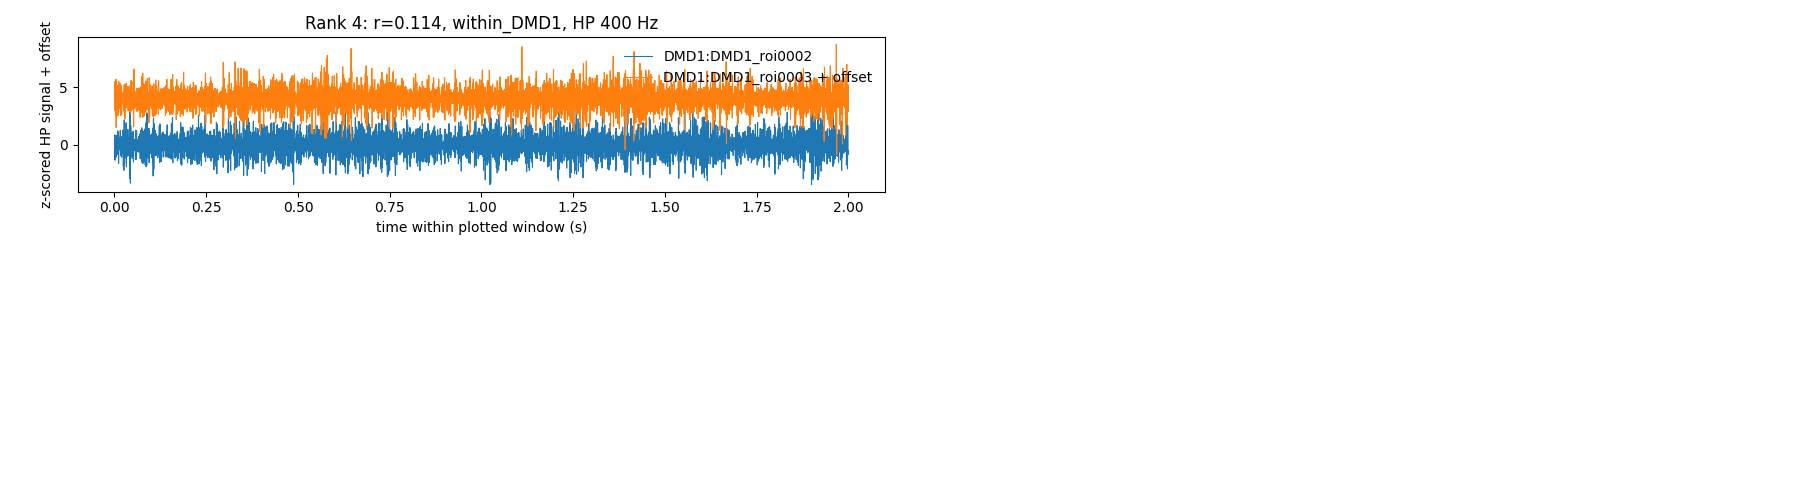

<IPython.core.display.Javascript object>


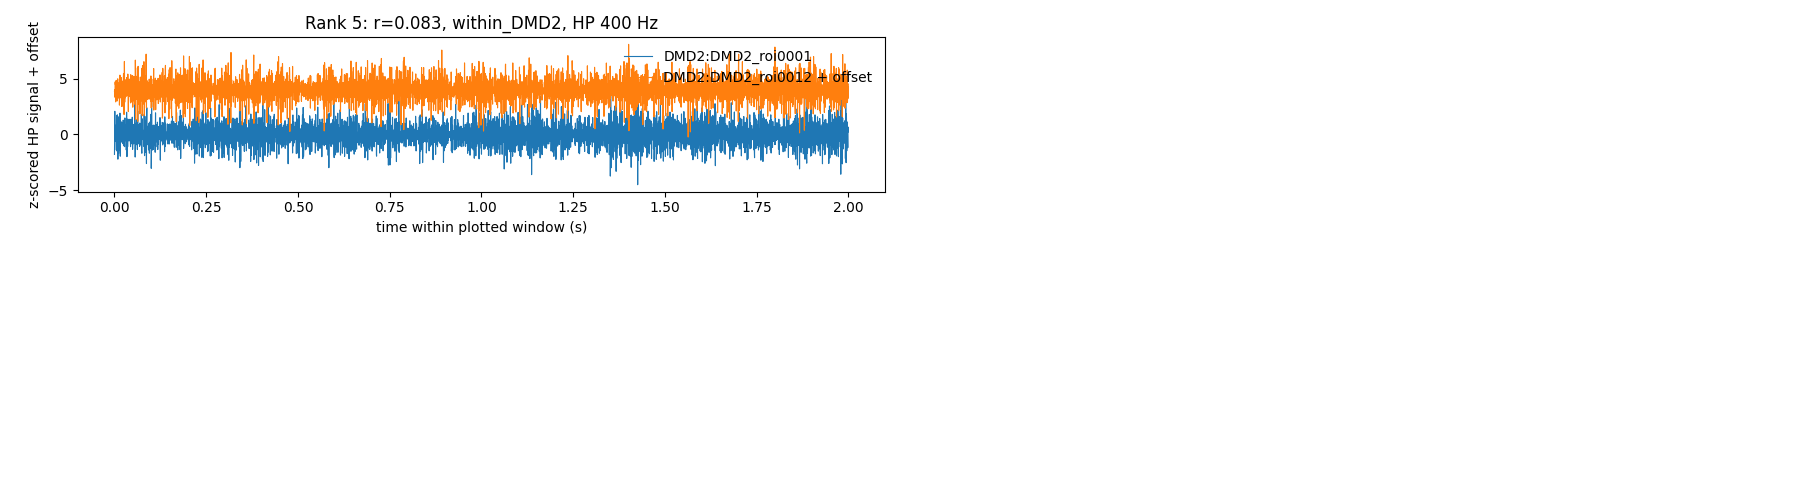

<IPython.core.display.Javascript object>


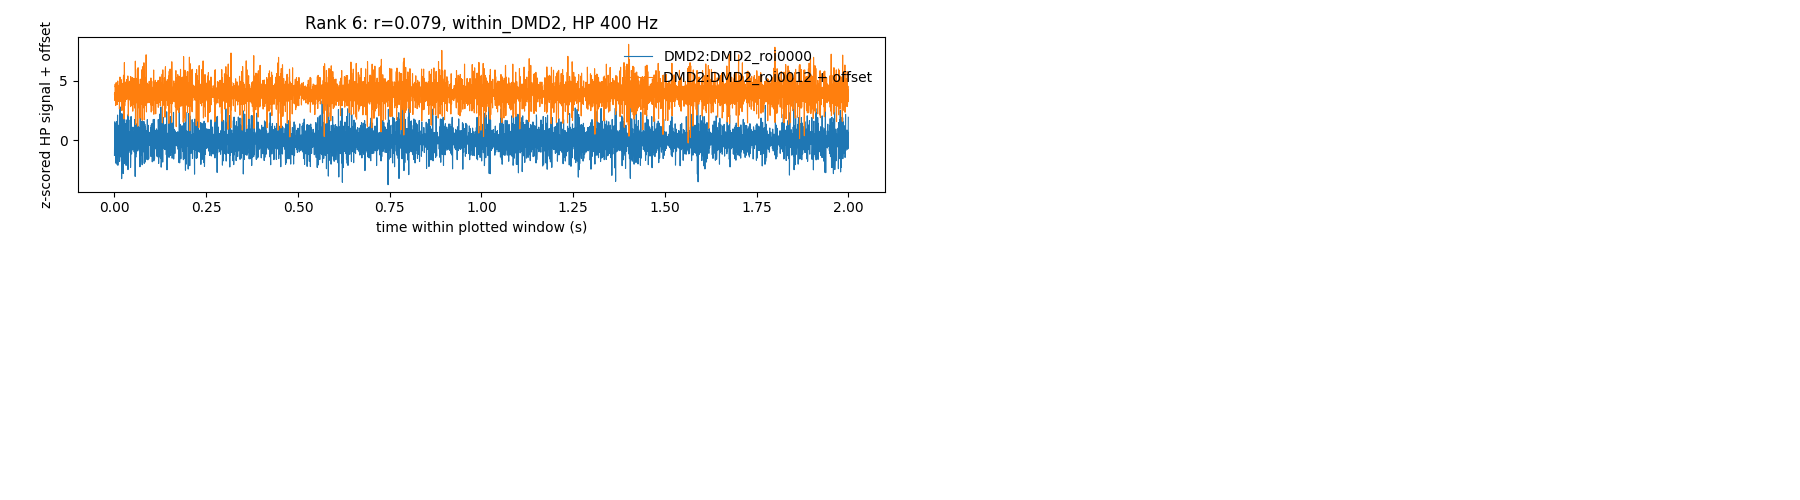

<IPython.core.display.Javascript object>


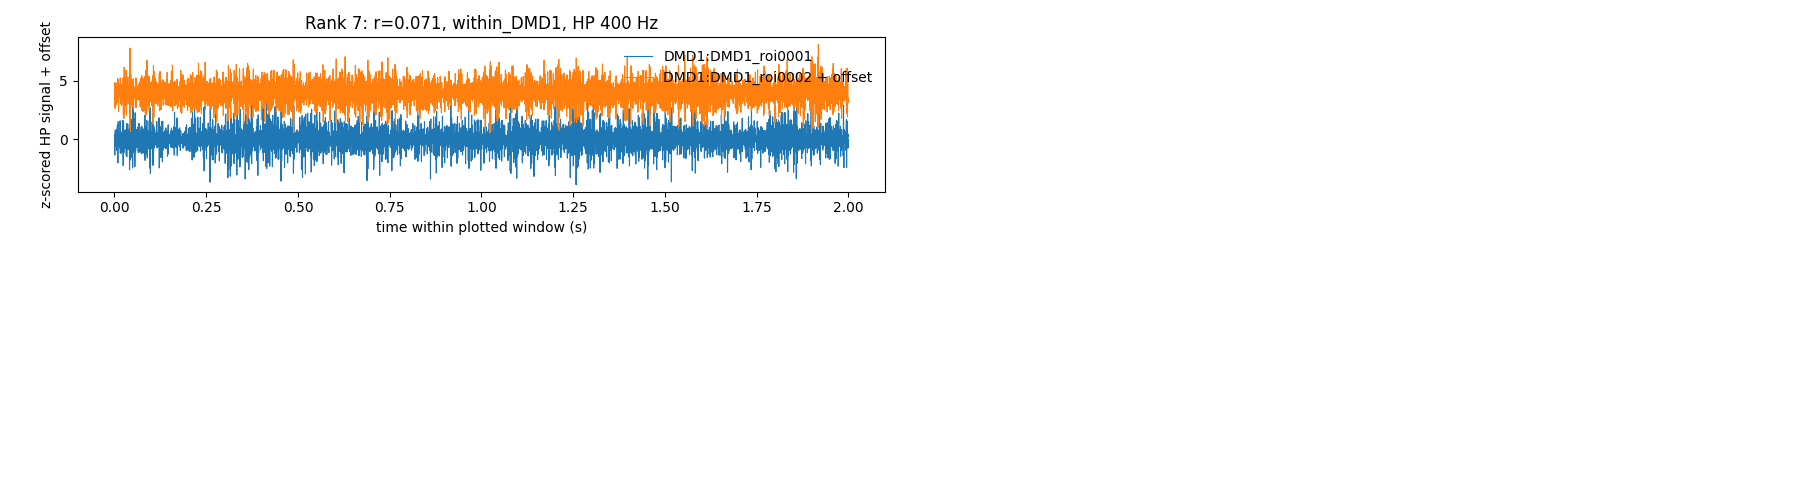

<IPython.core.display.Javascript object>


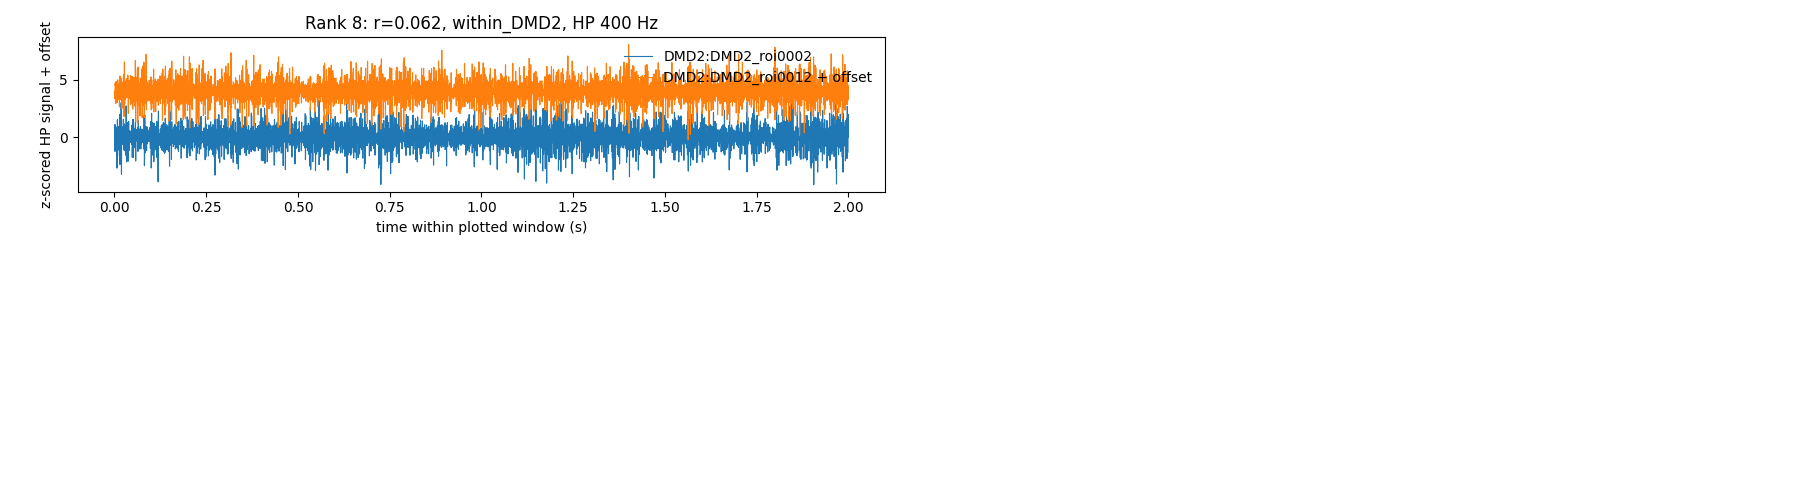

In [20]:
def plot_top_pair_traces(hp, pair_df, top_n=8, start_sec=30.0, window_sec=2.0):
    Xall, roi_df = build_combined_roi_matrix(hp)
    fs = float(hp["fs_hz"])
    n0 = int(round(start_sec * fs))
    n1 = int(round((start_sec + window_sec) * fs))
    n0 = max(0, min(n0, Xall.shape[1] - 2))
    n1 = max(n0 + 2, min(n1, Xall.shape[1]))
    t = np.arange(n1 - n0) / fs
    top = pair_df.sort_values("r", ascending=False).head(top_n).copy()

    for rank, (_, p) in enumerate(top.iterrows(), start=1):
        i, j = int(p["node_i"]), int(p["node_j"])
        x = Xall[i, n0:n1]
        y = Xall[j, n0:n1]
        x = (x - np.nanmean(x)) / (np.nanstd(x) + 1e-8)
        y = (y - np.nanmean(y)) / (np.nanstd(y) + 1e-8)
        fig, ax = plt.subplots(figsize=(9, 2.5))
        ax.plot(t, x, lw=0.8, label=p["label_i"])
        ax.plot(t, y + 4, lw=0.8, label=p["label_j"] + " + offset")
        ax.set_xlabel("time within plotted window (s)")
        ax.set_ylabel("z-scored HP signal + offset")
        ax.set_title(f"Rank {rank}: r={p['r']:.3f}, {p['pair_class']}, HP {hp['hp_hz']:g} Hz")
        ax.legend(frameon=False, loc="upper right")
        fig.tight_layout()
#         save_figure(fig, OUT_DIR, f"{today_str}_session{SESSION_INDEX}_hp{hp['hp_hz']:g}_top_pair_trace_rank{rank:02d}")

plot_top_pair_traces(
    best_hp_data,
    best_pair_df,
    top_n=PLOT_TOP_N_PAIRS,
    start_sec=TRACE_PLOT_START_SEC,
    window_sec=TRACE_PLOT_WINDOW_SEC,
)

## Save output tables

In [21]:
# Add session metadata to output tables.
for df in [scan_df, best_pair_df, candidate_edges_df, components_df, lag_summary_df, lag_curves_df]:
    if len(df):
        df["session_index"] = SESSION_INDEX
        df["trace_h5"] = str(trace_h5)
        df["signal"] = SIGNAL
        df["identity_max_seconds"] = IDENTITY_MAX_SECONDS
        df["best_hp_hz"] = best_hp
        df["identity_threshold"] = identity_threshold

scan_csv = OUT_DIR / f"{today_str}_session{SESSION_INDEX}_roi_identity_highpass_scan.csv"
pair_csv = OUT_DIR / f"{today_str}_session{SESSION_INDEX}_hp{best_hp:g}_roi_pair_correlations.csv"
candidates_csv = OUT_DIR / f"{today_str}_session{SESSION_INDEX}_hp{best_hp:g}_identity_candidate_edges.csv"
components_csv = OUT_DIR / f"{today_str}_session{SESSION_INDEX}_hp{best_hp:g}_identity_components.csv"
lag_summary_csv = OUT_DIR / f"{today_str}_session{SESSION_INDEX}_hp{best_hp:g}_lag_summary.csv"
lag_curves_csv = OUT_DIR / f"{today_str}_session{SESSION_INDEX}_hp{best_hp:g}_lag_curves.csv"

scan_df.to_csv(scan_csv, index=False)
best_pair_df.to_csv(pair_csv, index=False)
candidate_edges_df.to_csv(candidates_csv, index=False)
components_df.to_csv(components_csv, index=False)
if len(lag_summary_df):
    lag_summary_df.to_csv(lag_summary_csv, index=False)
if len(lag_curves_df):
    lag_curves_df.to_csv(lag_curves_csv, index=False)

print("Saved:", scan_csv)
print("Saved:", pair_csv)
print("Saved:", candidates_csv)
print("Saved:", components_csv)
if len(lag_summary_df):
    print("Saved:", lag_summary_csv)
if len(lag_curves_df):
    print("Saved:", lag_curves_csv)

Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_dendrite_roi_identity_clustering\2026-07-01_session0_roi_identity_highpass_scan.csv
Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_dendrite_roi_identity_clustering\2026-07-01_session0_hp400_roi_pair_correlations.csv
Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_dendrite_roi_identity_clustering\2026-07-01_session0_hp400_identity_candidate_edges.csv
Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_dendrite_roi_identity_clustering\2026-07-01_session0_hp400_identity_components.csv
Saved: C:\Users\andrew.shelton\Dropbox\a

## Interpretation notes

The thresholded graph gives candidate same-cell compartments. Before treating a component as a neuron, check:

1. Whether the candidate pair remains high at several nearby high-pass cutoffs.
2. Whether the lag peak is near zero.
3. Whether the candidate is not explained by a line-noise or motion artifact.
4. Whether the raw/full-band traces have plausible shared transients.
5. Whether reconstruction later supports the inferred identity.

For the next notebook stage, you can collapse candidate components into putative cells and ask whether within-cell cross-depth differences encode task variables differently from between-cell pairs.